In [1]:
import os

os.listdir('/kaggle/input')

['datasets']

In [2]:
os.listdir('/kaggle/input/datasets')

['navoneel']

In [3]:
os.listdir('/kaggle/input/datasets/navoneel')

['brain-mri-images-for-brain-tumor-detection']

In [4]:
os.listdir('/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection')

['no', 'yes', 'brain_tumor_dataset']

In [3]:
import numpy as np
import cv2
import os
import imutils
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications import InceptionV3

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [12]:
def crop_brain_contour(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    gray = cv2.GaussianBlur(gray, (5,5), 0)

    thresh = cv2.threshold(
        gray,
        45,
        255,
        cv2.THRESH_BINARY
    )[1]

    thresh = cv2.erode(thresh, None, iterations=2)

    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(
        thresh.copy(),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cnts = imutils.grab_contours(cnts)

    if len(cnts) > 0:

        c = max(cnts, key=cv2.contourArea)

        extLeft = tuple(c[c[:,:,0].argmin()][0])

        extRight = tuple(c[c[:,:,0].argmax()][0])

        extTop = tuple(c[c[:,:,1].argmin()][0])

        extBot = tuple(c[c[:,:,1].argmax()][0])

        new_image = image[
            extTop[1]:extBot[1],
            extLeft[0]:extRight[0]
        ]

        return new_image

    return image
    
   

In [13]:
def plot_training_history(history):

    acc = history.history['accuracy']

    val_acc = history.history['val_accuracy']

    loss = history.history['loss']

    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)

    plt.plot(epochs_range, acc)

    plt.plot(epochs_range, val_acc)

    plt.title('Accuracy')

    plt.legend(['Train', 'Validation'])

    plt.subplot(1,2,2)

    plt.plot(epochs_range, loss)

    plt.plot(epochs_range, val_loss)

    plt.title('Loss')

    plt.legend(['Train', 'Validation'])

    plt.show()

In [14]:
def find_dataset_path(base_path='/kaggle/input'):

    for root, dirs, files in os.walk(base_path):

        if 'yes' in dirs and 'no' in dirs:

            print(root)

            return root

    return None


DATASET_ROOT = find_dataset_path()

IMG_SIZE = (224,224)


/kaggle/input/datasets/navoneel/brain-mri-images-for-brain-tumor-detection


In [15]:
def load_data(dir_path, img_size):

    X = []

    y = []

    labels = {
        0:'no',
        1:'yes'
    }

    label_map = {
        'no':0,
        'yes':1
    }

    for class_name in ['no', 'yes']:

        folder_path = os.path.join(dir_path, class_name)

        for file_name in os.listdir(folder_path):

            if file_name.lower().endswith(('.png','.jpg','.jpeg')):

                img_path = os.path.join(folder_path, file_name)

                image = cv2.imread(img_path)

                image = crop_brain_contour(image)

                image = cv2.resize(
                    image,
                    dsize=img_size,
                    interpolation=cv2.INTER_CUBIC
                )

                image = image / 255.0

                X.append(image)

                y.append(label_map[class_name])

    X = np.array(X)

    y = np.array(y)

    print(len(X))

    return X, y, labels

In [16]:
X, y, labels = load_data(DATASET_ROOT, IMG_SIZE)

253


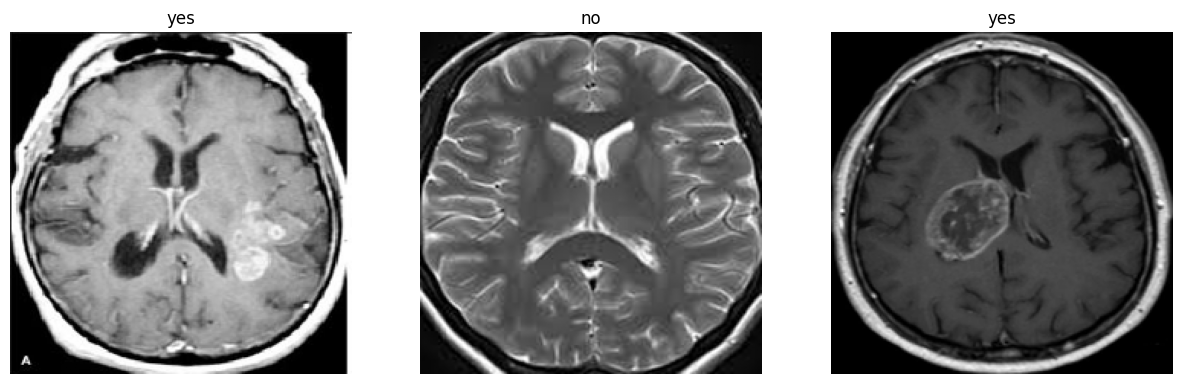

In [20]:
plt.figure(figsize=(15,5))

random_indices = random.sample(range(len(X)), 3)

for i, idx in enumerate(random_indices):

    plt.subplot(1,3,i+1)

    plt.imshow(X[idx])

    plt.title(labels[y[idx]])

    plt.axis('off')

plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)

print(X_test.shape)

(202, 224, 224, 3)
(51, 224, 224, 3)


In [19]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    horizontal_flip=True,
    fill_mode='nearest'
)

custom_callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=4,
        min_lr=1e-7
    )
]

In [10]:
import tensorflow as tf
import numpy as np
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [11]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

2026-05-15 08:50:53.525051: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [13]:
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),

    layers.BatchNormalization(),

    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [15]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 132,097 (516.00 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [17]:
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=15,
    callbacks=custom_callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 51s 7s/step - accuracy: 0.5146 - loss: 0.7786 - val_accuracy: 0.3922 - val_loss: 0.7471 - learning_rate: 1.0000e-04
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.6607 - loss: 0.6547 - val_accuracy: 0.3922 - val_loss: 0.7228 - learning_rate: 1.0000e-04
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 81s 8s/step - accuracy: 0.6799 - loss: 0.6005 - val_accuracy: 0.4118 - val_loss: 0.7052 - learning_rate: 1.0000e-04
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - accuracy: 0.6374 - loss: 0.6612 - val_accuracy: 0.4902 - val_loss: 0.6908 - learning_rate: 1.0000e-04
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.6700 - loss: 0.5901 - val_accuracy: 0.5882 - val_loss: 0.6757 - learning_rate: 1.0000e-04
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.7235 - loss: 0.5586 - val_accuracy: 0.6471 - val_loss: 0.6659 - learning_rate: 1.0000e-04
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.7434 - loss: 0.5435 - val_

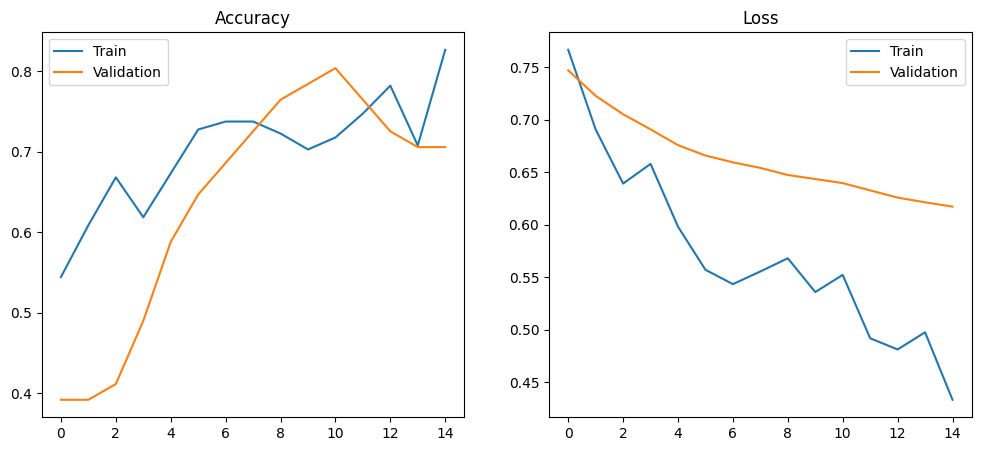

In [18]:
plot_training_history(history)

In [19]:
y_pred_probs = model.predict(X_test)

y_pred = (y_pred_probs > 0.5).astype("int32")

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step


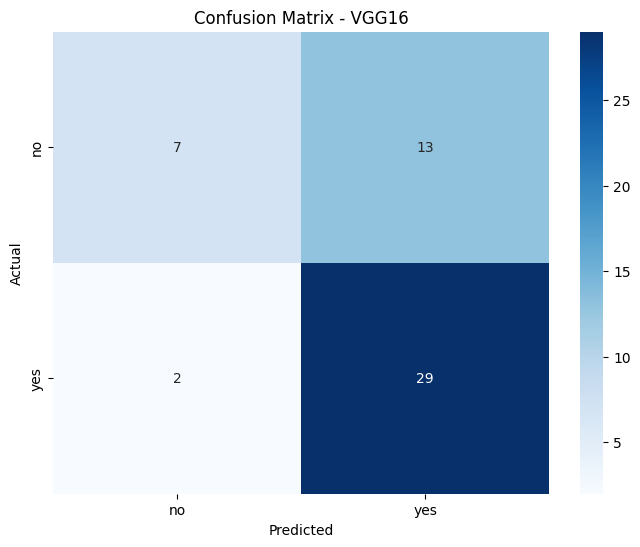

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels.values(),
    yticklabels=labels.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - VGG16")

plt.show()

In [21]:
print(classification_report(
    y_test,
    y_pred,
    target_names=labels.values()
))

              precision    recall  f1-score   support

          no       0.78      0.35      0.48        20
         yes       0.69      0.94      0.79        31

    accuracy                           0.71        51
   macro avg       0.73      0.64      0.64        51
weighted avg       0.72      0.71      0.67        51



In [22]:
def build_custom_cnn():

    model = models.Sequential([

        layers.Conv2D(
            32,
            (3,3),
            activation='relu',
            input_shape=(224,224,3)
        ),

        layers.MaxPooling2D((2,2)),

        layers.Conv2D(
            64,
            (3,3),
            activation='relu'
        ),

        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(
            128,
            activation='relu'
        ),

        layers.Dropout(0.5),

        layers.Dense(
            1,
            activation='sigmoid'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [23]:
custom_model = build_custom_cnn()

custom_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history_custom = custom_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=10,
    callbacks=custom_callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5394 - loss: 2.0005 - val_accuracy: 0.6863 - val_loss: 0.6258 - learning_rate: 0.0010
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 972ms/step - accuracy: 0.5640 - loss: 0.7424 - val_accuracy: 0.6863 - val_loss: 0.6617 - learning_rate: 0.0010
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 977ms/step - accuracy: 0.6409 - loss: 0.6413 - val_accuracy: 0.6863 - val_loss: 0.6575 - learning_rate: 0.0010
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 977ms/step - accuracy: 0.6270 - loss: 0.6735 - val_accuracy: 0.7451 - val_loss: 0.6217 - learning_rate: 0.0010
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 962ms/step - accuracy: 0.7247 - loss: 0.5905 - val_accuracy: 0.7255 - val_loss: 0.5838 - learning_rate: 0.0010
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 967ms/step - accuracy: 0.7457 - loss: 0.5602 - val_accuracy: 0.7647 - val_loss: 0.5768 - learning_rate: 0.0010
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 985ms/step - accuracy: 0.7908 - loss: 0.4982 - val_accuracy: 0.

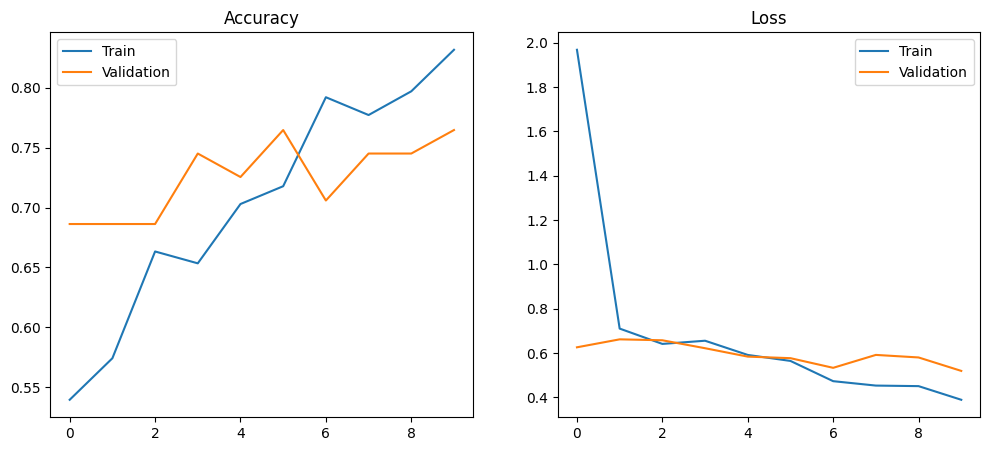

In [25]:
plot_training_history(history_custom)

In [26]:
y_pred_custom = (
    custom_model.predict(X_test) > 0.5
).astype("int32")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


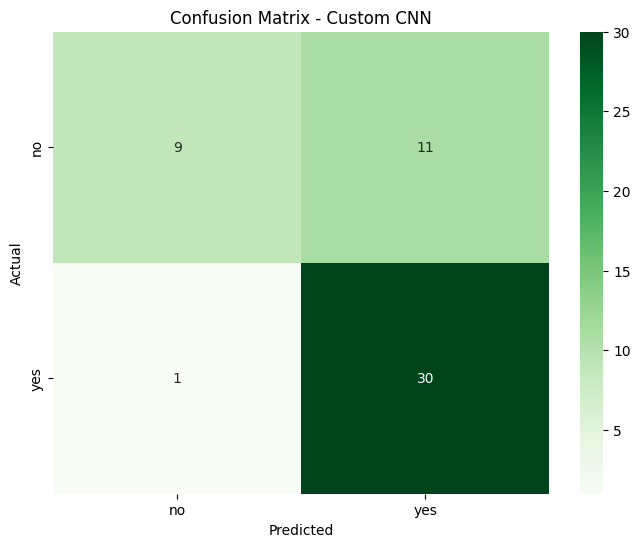

In [27]:
cm_custom = confusion_matrix(
    y_test,
    y_pred_custom
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_custom,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels.values(),
    yticklabels=labels.values()
)

plt.title("Confusion Matrix - Custom CNN")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:
from sklearn.metrics import classification_report

print("Custom CNN Classification Report:")
print(classification_report(
    y_test,
    y_pred_custom,
    target_names=["No Tumor", "Tumor"],
    zero_division=0
))

Custom CNN Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.90      0.45      0.60        20
       Tumor       0.73      0.97      0.83        31

    accuracy                           0.76        51
   macro avg       0.82      0.71      0.72        51
weighted avg       0.80      0.76      0.74        51



In [51]:
from tensorflow.keras.applications.resnet50 import (
    ResNet50,
    preprocess_input
)

In [52]:
base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [53]:
base_model_resnet.trainable = True

for layer in base_model_resnet.layers[:-10]:
    layer.trainable = False

In [54]:
resnet_model = models.Sequential([

    layers.Lambda(
        lambda x: preprocess_input(x * 255.0),
        input_shape=(224,224,3)
    ),

    base_model_resnet,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        1,
        activation='sigmoid'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [55]:
resnet_model.compile(
    optimizer=optimizers.Adam(
        learning_rate=1e-5
    ),

    loss='binary_crossentropy',

    metrics=['accuracy']
)

In [56]:
resnet_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 4,990,465 (19.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

In [57]:
history_resnet = resnet_model.fit(
    train_datagen.flow(
        X_train,
        y_train,
        batch_size=16
    ),

    validation_data=(X_test, y_test),

    epochs=15,

    callbacks=custom_callbacks,

    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.5405 - loss: 0.8917 - val_accuracy: 0.6078 - val_loss: 0.6992 - learning_rate: 1.0000e-05
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6321 - loss: 0.7348 - val_accuracy: 0.6275 - val_loss: 0.5795 - learning_rate: 1.0000e-05
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6572 - loss: 0.6346 - val_accuracy: 0.7451 - val_loss: 0.5171 - learning_rate: 1.0000e-05
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6676 - loss: 0.5376 - val_accuracy: 0.7843 - val_loss: 0.4808 - learning_rate: 1.0000e-05
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7981 - loss: 0.4618 - val_accuracy: 0.8039 - val_loss: 0.4483 - learning_rate: 1.0000e-05
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7698 - loss: 0.4901 - val_accuracy: 0.8431 - val_loss: 0.4089 - learning_rate: 1.0000e-05
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8195 - loss:

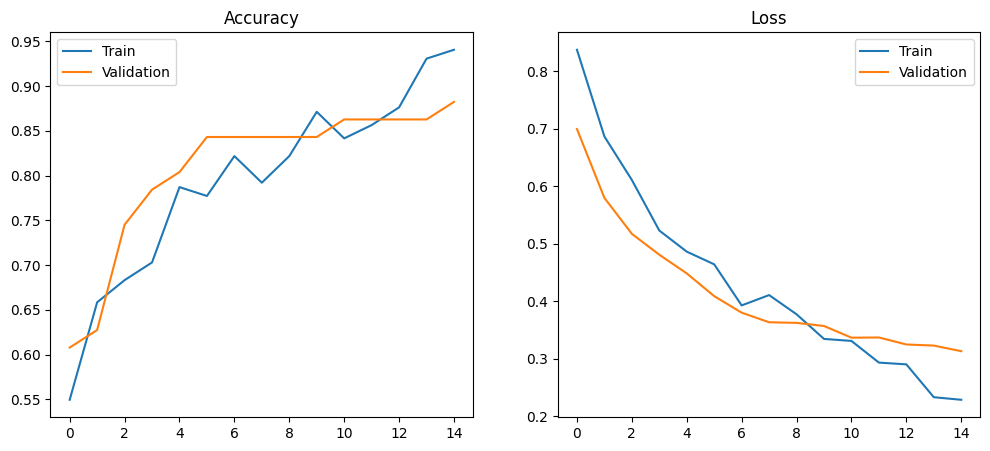

In [65]:
plot_training_history(history_resnet)

In [66]:
y_pred_res = (
    resnet_model.predict(X_test) > 0.5
).astype("int32")

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step


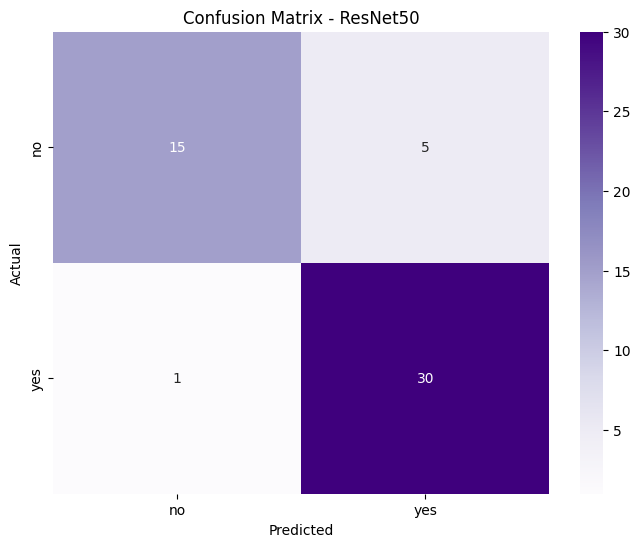

In [67]:
cm_res = confusion_matrix(
    y_test,
    y_pred_res
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_res,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=labels.values(),
    yticklabels=labels.values()
)

plt.title("Confusion Matrix - ResNet50")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [68]:
print(classification_report(
    y_test,
    y_pred_res,
    target_names=labels.values()
))

              precision    recall  f1-score   support

          no       0.94      0.75      0.83        20
         yes       0.86      0.97      0.91        31

    accuracy                           0.88        51
   macro avg       0.90      0.86      0.87        51
weighted avg       0.89      0.88      0.88        51



In [43]:
from tensorflow.keras.applications import InceptionV3

base_model_google = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_google.trainable = False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [44]:
google_model = models.Sequential([
    
    base_model_google,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(256, activation='relu'),
    
    layers.Dropout(0.5),
    
    layers.Dense(1, activation='sigmoid')
])

google_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
google_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,327,585 (85.17 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [46]:
history_google = google_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=10,
    callbacks=custom_callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5998 - loss: 1.0585 - val_accuracy: 0.7255 - val_loss: 0.5197 - learning_rate: 0.0010
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7866 - loss: 0.4871 - val_accuracy: 0.8627 - val_loss: 0.3811 - learning_rate: 0.0010
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7996 - loss: 0.4445 - val_accuracy: 0.8431 - val_loss: 0.3351 - learning_rate: 0.0010
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8329 - loss: 0.4494 - val_accuracy: 0.8235 - val_loss: 0.3500 - learning_rate: 0.0010
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8616 - loss: 0.3318 - val_accuracy: 0.8039 - val_loss: 0.3393 - learning_rate: 0.0010
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8674 - loss: 0.2744 - val_accuracy: 0.8431 - val_loss: 0.3556 - learning_rate: 0.0010
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8927 - loss: 0.2581 - val_accuracy: 0.8431 - val_l

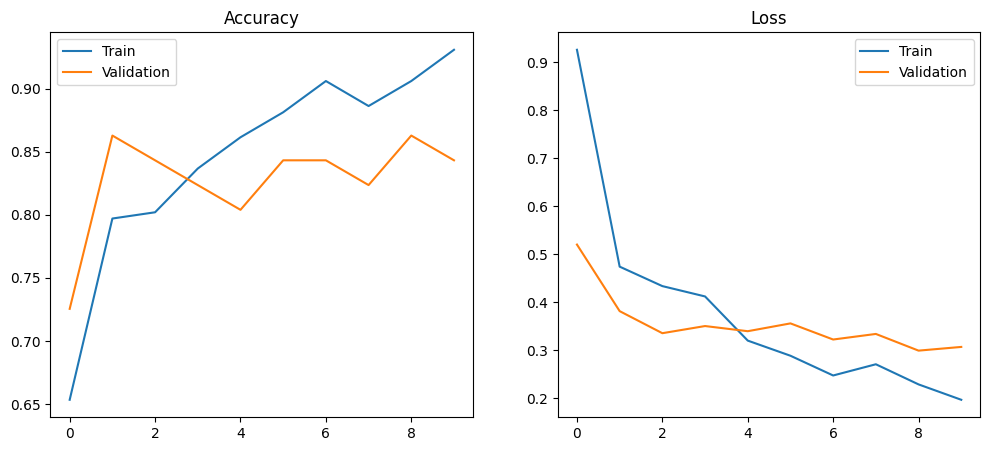

In [47]:
plot_training_history(history_google )

In [48]:
y_pred_google = (
    google_model.predict(X_test) > 0.5
).astype("int32")

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step


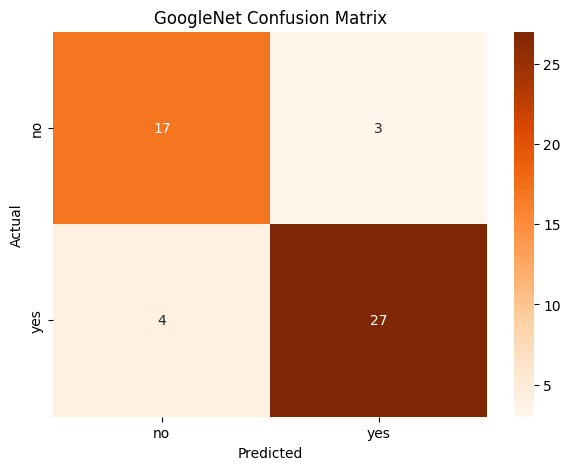

In [49]:
cm_google = confusion_matrix(
    y_test,
    y_pred_google
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_google,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=labels.values(),
    yticklabels=labels.values()
)

plt.title("GoogleNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [50]:
print(classification_report(
    y_test,
    y_pred_google,
    target_names=labels.values()
))

              precision    recall  f1-score   support

          no       0.81      0.85      0.83        20
         yes       0.90      0.87      0.89        31

    accuracy                           0.86        51
   macro avg       0.85      0.86      0.86        51
weighted avg       0.86      0.86      0.86        51



In [69]:
results = {
    'Model': [
        'VGG16',
        'Custom CNN',
        'ResNet50',
        'GoogleNet'
    ],
    
    'Accuracy': [
        max(history.history['val_accuracy']),
        max(history_custom.history['val_accuracy']),
        max(history_resnet.history['val_accuracy']),
        max(history_google.history['val_accuracy'])
    ]
}

results_df = pd.DataFrame(results)

results_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,ResNet50,0.882353
3,GoogleNet,0.862745
0,VGG16,0.803922
1,Custom CNN,0.764706


In [70]:
display(results_df)

,Model,Accuracy
0,VGG16,0.803922
1,Custom CNN,0.764706
2,ResNet50,0.882353
3,GoogleNet,0.862745


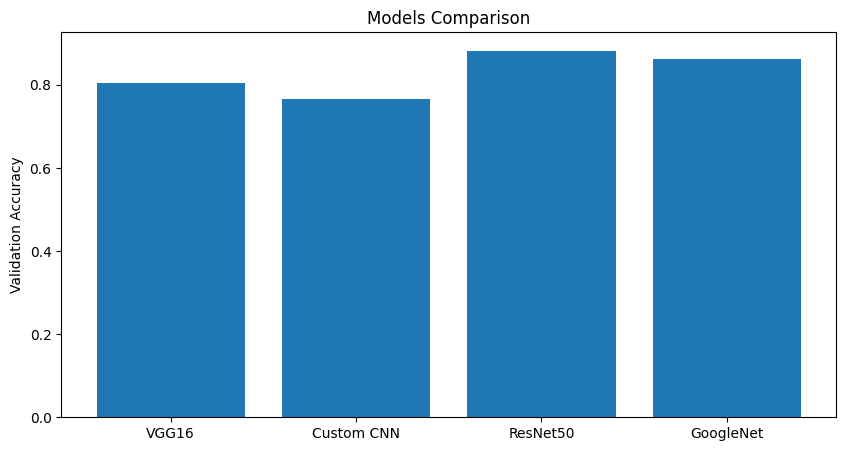

In [71]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df['Model'],
    results_df['Accuracy']
)

plt.title("Models Comparison")
plt.ylabel("Validation Accuracy")

plt.show()

In [94]:
# ==============================
# SAVE MODEL
# ==============================

clean_model.save("/kaggle/working/brain_tumor_model.keras")

print("✅ MODEL SAVED SUCCESSFULLY")

✅ MODEL SAVED SUCCESSFULLY


In [87]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, Lambda
from tensorflow.keras.applications import ResNet50
import tensorflow as tf

# ==============================
# Base Model
# ==============================

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# ==============================
# SAME ORIGINAL ARCHITECTURE
# ==============================

inputs = Input(shape=(224,224,3))


x = Lambda(lambda z: z)(inputs)

x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

outputs = Dense(1, activation='sigmoid')(x)

clean_model = Model(inputs, outputs)

# ==============================
# Transfer Weights
# ==============================

clean_model.set_weights(resnet_model.get_weights())

print("✅ Weights transferred successfully")

# ==============================
# EXPORT MODEL
# ==============================

clean_model.export("/kaggle/working/final_model")

print("✅ FINAL MODEL EXPORTED SUCCESSFULLY")

✅ Weights transferred successfully
INFO:tensorflow:Assets written to: /kaggle/working/final_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/final_model/assets


Saved artifact at '/kaggle/working/final_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_1086')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132406575213328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132406575215056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132406575215440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132406575215632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132406575215248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132406575214480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132406575216400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132406575215824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132406575211408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132406575217936: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [24]:
import os

print(os.listdir('/kaggle/working'))

['app.py', '.virtual_documents']


In [42]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
from datetime import datetime
from tensorflow.keras.applications.resnet50 import preprocess_input

# ==============================
# Load Model
# ==============================

import os
import tensorflow as tf
import numpy as np

@st.cache_resource
def load_my_model():

    model_dir = "/kaggle/input/models/mariam23darwish/brain-tumor-model-1/tensorflow1/default/1"

    model_file = os.listdir(model_dir)[0]

    full_path = os.path.join(model_dir, model_file)

    model = tf.keras.models.load_model(full_path, safe_mode=False)

    return model

model = load_my_model()

# ==============================
# Page Config
# ==============================

st.set_page_config(
    page_title="Brain Tumor Detection AI",
    page_icon="🧠",
    layout="wide"
)

# ==============================
# Custom CSS
# ==============================

st.markdown("""
<style>

.stApp {
    background-color: #0B0F19;
    color: white;
}

/* Main Title */
.title {
    text-align: center;
    font-size: 52px;
    font-weight: bold;
    color: #00E5FF;
    margin-top: 10px;
    margin-bottom: 5px;
}

/* Subtitle */
.subtitle {
    text-align: center;
    color: #B0BEC5;
    font-size: 18px;
    margin-bottom: 35px;
}

/* Cards */
.section-card {
    background-color: #111827;
    padding: 25px;
    border-radius: 22px;
    border: 1px solid #1F2937;
    box-shadow: 0px 0px 25px rgba(0,229,255,0.12);
}

/* Result Box */
.result-box {
    padding: 30px;
    border-radius: 22px;
    text-align: center;
    margin-top: 20px;
    box-shadow: 0px 0px 25px rgba(0,0,0,0.3);
}

/* Report */
.report-box {
    background-color: #111827;
    padding: 22px;
    border-radius: 18px;
    margin-top: 25px;
    border-left: 5px solid #00E5FF;
    line-height: 2;
}

/* Footer */
.footer {
    text-align: center;
    color: gray;
    margin-top: 50px;
    font-size: 15px;
}

/* Labels */
label {
    color: white !important;
    font-weight: bold !important;
    font-size: 17px !important;
}

/* Text Input */
.stTextInput input {
    background-color: #F3F4F6 !important;
    color: black !important;
    border-radius: 10px !important;
    border: 2px solid #374151 !important;
    font-weight: bold !important;
}

/* Number Input */
.stNumberInput input {
    background-color: #F3F4F6 !important;
    color: black !important;
    border-radius: 10px !important;
    border: 2px solid #374151 !important;
    font-weight: bold !important;
}

/* Select Box */
.stSelectbox div[data-baseweb="select"] {
    background-color: #F3F4F6 !important;
    color: black !important;
    border-radius: 10px !important;
    font-weight: bold !important;
}

/* File Uploader Label */
.stFileUploader label {
    color: white !important;
    font-weight: bold !important;
    font-size: 17px !important;
}

/* Upload Button */
.stFileUploader button {
    background-color: #00E5FF !important;
    color: black !important;
    font-weight: bold !important;
    border-radius: 10px !important;
    border: none !important;
    padding: 10px 18px !important;
}

/* Upload Button Hover */
.stFileUploader button:hover {
    background-color: #00B8D4 !important;
    color: white !important;
}

/* Upload Area */
.stFileUploader div[data-testid="stFileUploaderDropzone"] {
    background-color: #1E293B !important;
    border: 2px dashed #00E5FF !important;
    border-radius: 15px !important;
    padding: 20px !important;
    color: white !important;
}

</style>
""", unsafe_allow_html=True)

# ==============================
# Header
# ==============================

st.markdown(
    '<div class="title">🧠 Brain Tumor Detection AI System</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">AI-powered MRI Brain Scan Analysis using Deep Learning</div>',
    unsafe_allow_html=True
)

# ==============================
# Patient Information
# ==============================

st.markdown("## 👨‍⚕️ Patient Information")

col1, col2, col3 = st.columns(3)

with col1:
    patient_name = st.text_input(
        "👤 Patient Name",
        placeholder="Enter patient name"
    )

with col2:
    patient_age = st.number_input(
        "🎂 Age",
        min_value=1,
        max_value=100,
        value=20
    )

with col3:
    patient_gender = st.selectbox(
        "⚧ Gender",
        ["Female", "Male"]
    )

st.markdown("---")

# ==============================
# Upload MRI
# ==============================

st.markdown("## 📤 Upload MRI Scan")

uploaded_file = st.file_uploader(
    "🖼️ Choose MRI Image",
    type=["jpg", "jpeg", "png"]
)

# ==============================
# Prediction
# ==============================

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    left_col, right_col = st.columns([1,1])

    # ==============================
    # MRI IMAGE
    # ==============================

    with left_col:

        st.markdown('<div class="section-card">', unsafe_allow_html=True)

        st.image(
            image,
            caption="Uploaded MRI Scan",
            use_container_width=True
        )

        st.markdown('</div>', unsafe_allow_html=True)

    # ==============================
    # AI ANALYSIS
    # ==============================

    with right_col:

        with st.spinner("🔍 AI is analyzing MRI scan..."):

            image = image.resize((224,224))

            img_array = np.array(image)

            img_array = np.expand_dims(img_array, axis=0)

            img_array = img_array.astype(np.float32)

            img_array = preprocess_input(img_array)

            prediction = model(img_array, training=False).numpy()

            prediction = float(prediction[0])

        st.markdown("## 📊 AI Diagnosis")

        # ==============================
        # DECISION LOGIC
        # ==============================

        if prediction >= 0.60:

            confidence = prediction * 100

            result = "🧠 Tumor Detected"

            recommendation = """
            High probability of brain tumor detected.
            Immediate consultation with a neurologist is recommended.
            """

            bg_color = "#3B0D0D"
            text_color = "#FF4B4B"
            border_color = "#FF4B4B"

        elif 0.40 <= prediction < 0.60:

            confidence = prediction * 100

            result = "⚠️ Uncertain Result"

            recommendation = """
            MRI scan requires further medical review.
            Additional imaging and specialist consultation recommended.
            """

            bg_color = "#4A3419"
            text_color = "#FFC107"
            border_color = "#FFC107"

        else:

            confidence = (1 - prediction) * 100

            result = "✅ No Tumor Detected"

            recommendation = """
            No significant tumor indicators detected in MRI scan.
            Continue regular medical follow-up if symptoms persist.
            """

            bg_color = "#0D2E1C"
            text_color = "#00E676"
            border_color = "#00E676"

        # ==============================
        # RESULT BOX
        # ==============================

        st.markdown(f"""
        <div class="result-box"
        style="
            background-color:{bg_color};
            border:2px solid {border_color};
        ">

        <h1 style="color:{text_color};">
        {result}
        </h1>

        <h3 style="color:white;">
        📈 Confidence Level: {confidence:.2f}%
        </h3>

        </div>
        """, unsafe_allow_html=True)

        # Progress Bar
        st.progress(int(confidence))

        # Raw Score
        st.markdown(
            f"### 🔢 Raw Prediction Score: `{prediction:.4f}`"
        )

        # ==============================
        # MEDICAL REPORT
        # ==============================

        current_time = datetime.now().strftime("%Y-%m-%d %H:%M")

        st.markdown(f"""
        <div class="report-box">

        <h2>📋 AI Medical Report</h2>

        <hr>

        <b>👤 Patient Name:</b> {patient_name if patient_name else "Not Provided"} <br>

        <b>🎂 Age:</b> {patient_age} <br>

        <b>⚧ Gender:</b> {patient_gender} <br>

        <b>📅 Scan Date:</b> {current_time} <br>

        <b>🧠 AI Diagnosis:</b> {result} <br>

        <b>📈 Confidence:</b> {confidence:.2f}% <br>

        <b>🩺 Recommendation:</b><br>
        {recommendation}

        </div>
        """, unsafe_allow_html=True)

# ==============================
# Footer
# ==============================

st.markdown(
    """
    <div class="footer">
        Machine Learning Project • Brain Tumor Detection System <br>
        Powered by ResNet50 & Streamlit
    </div>
    """,
    unsafe_allow_html=True
)

Overwriting app.py


In [43]:
!pip install streamlit pyngrok --quiet

from pyngrok import ngrok
import threading
import os
import time

# ==============================
# NGROK TOKEN
# ==============================

ngrok.set_auth_token("3DSZqdDP57pwC8PIGHL9jTWb7qG_Vo5LSbZkbVDiHpQDn78z")

# ==============================
# Kill Previous Tunnels
# ==============================

!pkill ngrok

ngrok.kill()

# ==============================
# Run Streamlit
# ==============================

def run_streamlit():
    os.system("streamlit run app.py --server.port 8501")

thread = threading.Thread(target=run_streamlit)

thread.start()

# ==============================
# Wait for Streamlit
# ==============================

time.sleep(20)

# ==============================
# Create Public URL
# ==============================

public_url = ngrok.connect(8501)

print("🌍 Streamlit App URL:")
print(public_url)

🌍 Streamlit App URL:
NgrokTunnel: "https://refried-musty-consensus.ngrok-free.dev" -> "http://localhost:8501"


2026-05-16 10:26:19.167 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_13']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/kaggle/working/app.py:277: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction = float(prediction[0])
2026-05-16 10:26:45.626 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`,